In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from matplotlib import pyplot as plt
import seaborn as sns

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/202618002/DS605/LAB03/hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [7]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [8]:
print(df["is_canceled"].unique().tolist())
print(df["is_canceled"].value_counts())


[0, 1]
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [9]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [10]:
df.isnull().mean()*100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


## Which columns to remove?

### 1. The column 'company' has 94.3% of missing values. So, it can't give us any info. So, we remove it.

### 2. The columns reservation_status and reservation_status_date leak info about the test set. So, we remove them too.

In [11]:
df.drop(['company', 'reservation_status','reservation_status_date'], axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [13]:
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

In [14]:
numerical_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

if "agent" in numerical_cols:
    numerical_cols.remove("agent")
    categorical_cols.append("agent")

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'agent']


## Outlier removal

### Let's consider the numeric columns which aren't representing time - arrival_date_year, arrival_date_week_number, arrival_date_day_of_month

### 'Is_repeated_guest' is a binary variable so we will drop that too. 'Agent' shows the agent ID so there is no point in including it too.

In [15]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col:35} {count:>6} potential outliers")

lead_time                             3005 potential outliers
arrival_date_year                        0 potential outliers
arrival_date_week_number                 0 potential outliers
arrival_date_day_of_month                0 potential outliers
stays_in_weekend_nights                265 potential outliers
stays_in_week_nights                  3354 potential outliers
adults                               29710 potential outliers
children                              8590 potential outliers
babies                                 917 potential outliers
is_repeated_guest                     3810 potential outliers
previous_cancellations                6484 potential outliers
previous_bookings_not_canceled        3620 potential outliers
booking_changes                      18076 potential outliers
days_in_waiting_list                  3698 potential outliers
adr                                   3793 potential outliers
required_car_parking_spaces           7416 potential outliers
total_of

In [16]:
outlier_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

iqr_results = []

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    iqr_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count
    })

iqr_results = pd.DataFrame(iqr_results)

display(iqr_results)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005
1,stays_in_weekend_nights,0.00,2.0,2.00,-3.000,5.000,265
2,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354
3,adults,2.00,2.0,0.00,2.000,2.000,29710
4,children,0.00,0.0,0.00,0.000,0.000,8590
5,babies,0.00,0.0,0.00,0.000,0.000,917
6,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484
7,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3620
8,booking_changes,0.00,0.0,0.00,0.000,0.000,18076
9,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698


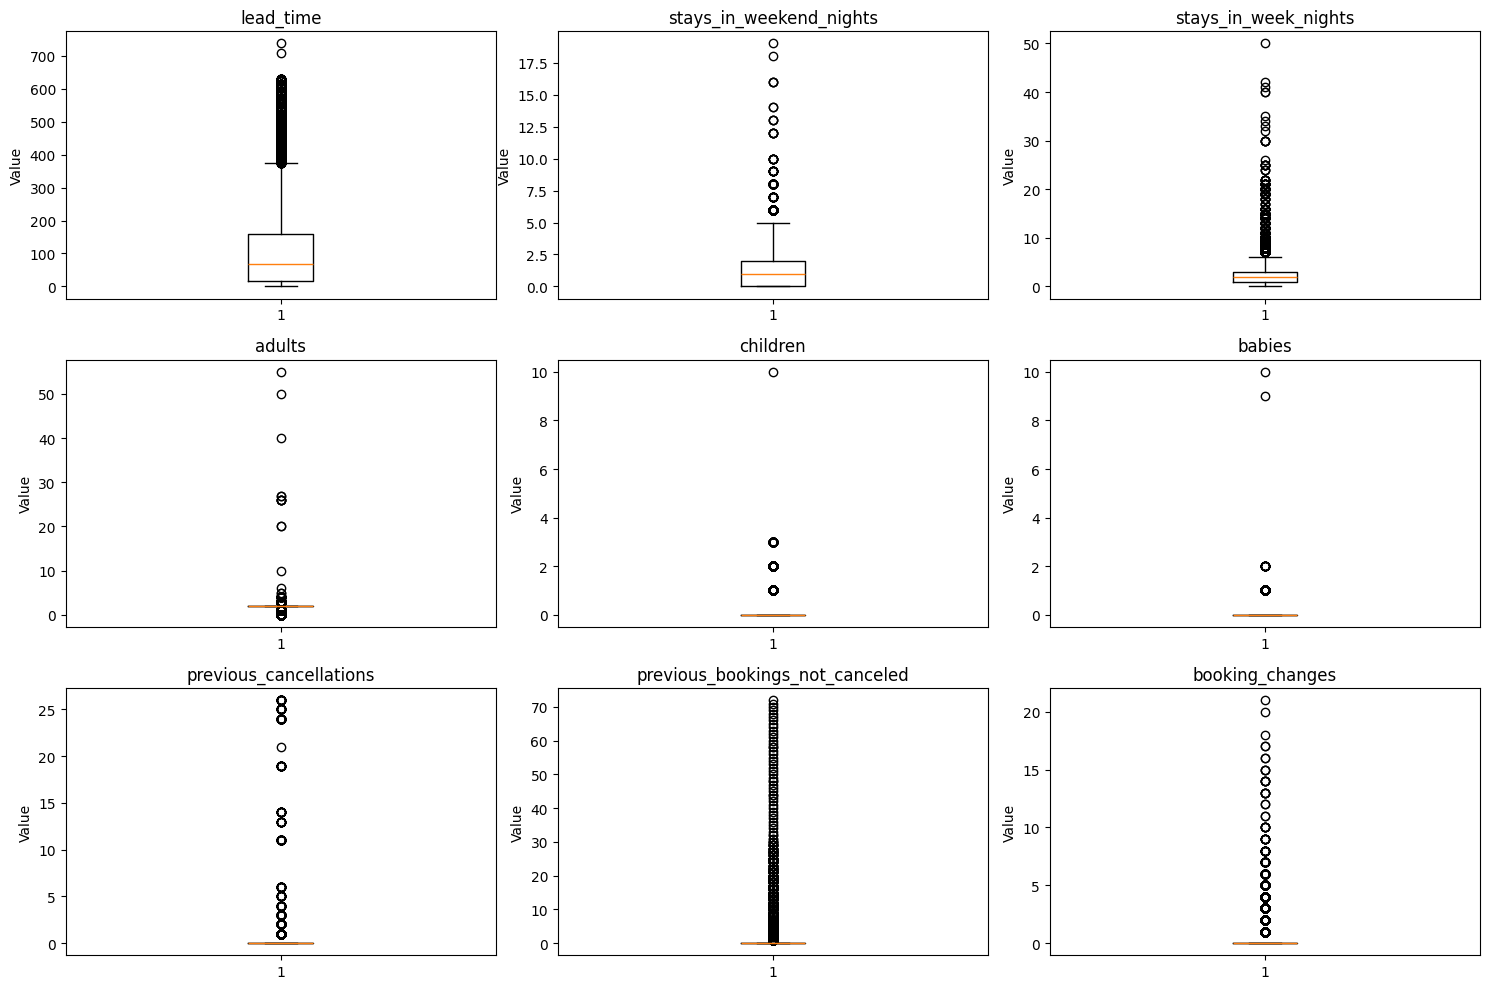

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.flatten(), outlier_cols[:9]):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

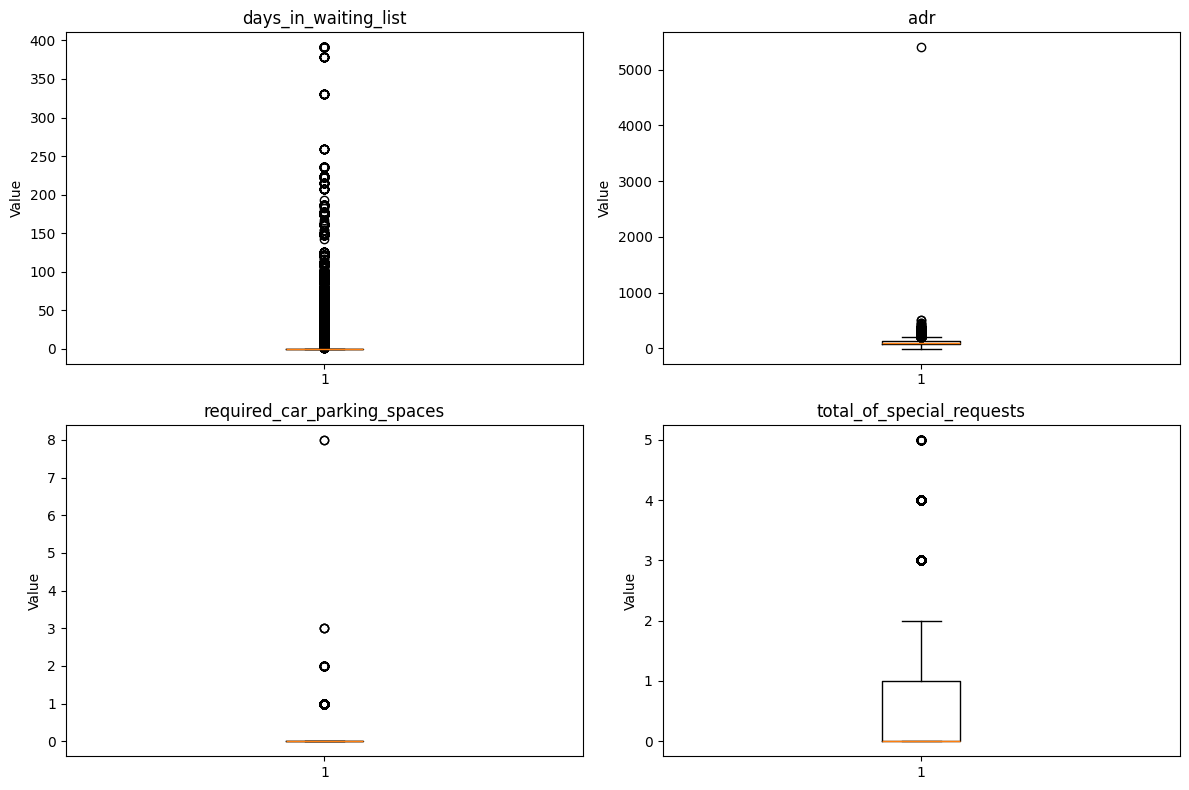

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), outlier_cols[9:]):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [19]:
# Identify bookings with no guests
zero_guest = (
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
)

print("Bookings with zero guests:", zero_guest.sum())

Bookings with zero guests: 180


In [20]:
before = len(df)

df = df[~zero_guest]

print("Rows removed:", before - len(df))
print("Rows remaining:", len(df))

Rows removed: 180
Rows remaining: 119210


Out of all the outliers, the adr column seems interesting. Let's analyse it a bit more.

In [21]:
print("Minimum ADR:", df["adr"].min())
print("Maximum ADR:", df["adr"].max())

print("\nLowest ADR values:")
display(df.nsmallest(10, "adr")[["adr", "hotel", "adults", "children", "babies"]])

print("\nHighest ADR values:")
display(df.nlargest(10, "adr")[["adr", "hotel", "adults", "children", "babies"]])

Minimum ADR: -6.38
Maximum ADR: 5400.0

Lowest ADR values:


,adr,hotel,adults,children,babies
14969,-6.38,Resort Hotel,2,0.0,0
0,0.00,Resort Hotel,2,0.0,0
1,0.00,Resort Hotel,2,0.0,0
125,0.00,Resort Hotel,4,0.0,0
167,0.00,Resort Hotel,2,0.0,0
168,0.00,Resort Hotel,1,0.0,0
196,0.00,Resort Hotel,2,0.0,0
197,0.00,Resort Hotel,2,0.0,0
421,0.00,Resort Hotel,2,0.0,0
428,0.00,Resort Hotel,1,0.0,0



Highest ADR values:


,adr,hotel,adults,children,babies
48515,5400.00,City Hotel,2,0.0,0
111403,510.00,City Hotel,1,0.0,0
15083,508.00,Resort Hotel,2,0.0,0
103912,451.50,City Hotel,2,2.0,0
13142,450.00,Resort Hotel,2,0.0,0
13391,437.00,Resort Hotel,2,2.0,0
39155,426.25,Resort Hotel,2,2.0,0
39568,402.00,Resort Hotel,3,1.0,0
39118,397.38,Resort Hotel,3,2.0,0
13323,392.00,Resort Hotel,2,1.0,0


At minimum, a negative ADR is clearly invalid

In [22]:
before = len(df)

df = df[(df["adr"] >= 0) & (df["adr"]<=5000)]

print("Rows removed due to invalid ADR:", before - len(df))

Rows removed due to invalid ADR: 2


In [23]:
df['adr']

,adr
0,0.00
1,0.00
2,75.00
3,75.00
4,98.00
...,...
119385,96.14
119386,225.43
119387,157.71
119388,104.40


In [24]:
print("Final dataset shape after Task 2:", df.shape)

Final dataset shape after Task 2: (119208, 29)


## TASK 3

In [26]:
y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119208, 28)
y shape: (119208,)


In [34]:
y.value_counts()

,count
is_canceled,
0,75010
1,44198


There is a class imbalance here. So, we stratify y during train test split.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (95366, 28)
Testing set: (23842, 28)

Training target distribution:
is_canceled
0    0.629239
1    0.370761
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629226
1    0.370774
Name: proportion, dtype: float64


In [35]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

In [37]:
numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

In [38]:
preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [39]:
preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

Pipeline A → StandardScaler

Pipeline B → MinMaxScaler

In [40]:
print("Pipeline A:")
print(preprocessor_A)

print("\nPipeline B:")
print(preprocessor_B)

Pipeline A:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_cancel...
                                  'adr', 'required_car_parking_spaces',
                                  'total_of_special_requests']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                           

At the end of task 3, we have this particular structure:

preprocessor_A

    -- KNNImputer(5) + StandardScaler

    -- SimpleImputer(most_frequent) + OneHotEncoder

preprocessor_B

    -- KNNImputer(5) + MinMaxScaler

    -- SimpleImputer(most_frequent) + OneHotEncoder

# PART 4

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

In [42]:
logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type',
                                                   'agent'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [43]:
logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type',
                                                   'agent'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type',
                                                   'agent'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [45]:
tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type',
                                                   'agent'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

## TASK 5

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [49]:
results = []

for name, model in models.items():

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Testing metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression + StandardScaler,0.833379,0.829083,0.814438,0.698077,0.751782
1,Logistic Regression + MinMaxScaler,0.829174,0.825057,0.810563,0.689253,0.745002
2,Decision Tree + StandardScaler,0.996309,0.863980,0.815608,0.818100,0.816852
3,Decision Tree + MinMaxScaler,0.996309,0.863938,0.815730,0.817760,0.816744


In [51]:
results_df["Train-Test Gap"] = (
    results_df["Training Accuracy"] -
    results_df["Testing Accuracy"]
)

results_df["Train-Test Gap"] = results_df["Train-Test Gap"].round(4)

display(results_df)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score,Train-Test Gap
0,Logistic Regression + StandardScaler,0.833379,0.829083,0.814438,0.698077,0.751782,0.0043
1,Logistic Regression + MinMaxScaler,0.829174,0.825057,0.810563,0.689253,0.745002,0.0041
2,Decision Tree + StandardScaler,0.996309,0.863980,0.815608,0.818100,0.816852,0.1323
3,Decision Tree + MinMaxScaler,0.996309,0.863938,0.815730,0.817760,0.816744,0.1324


In [63]:
logistic_results = results_df[
    results_df["Model"].str.startswith("Logistic Regression")
]

best_logistic = logistic_results.loc[
    logistic_results["F1 Score"].idxmax()
]

best_logistic_name = best_logistic["Model"]
best_logistic_model = models[best_logistic_name]

print("\nBest Logistic Regression:")
print(best_logistic_name)


Best Logistic Regression:
Logistic Regression + StandardScaler


In [64]:
tree_results = results_df[
    results_df["Model"].str.startswith("Decision Tree")
]

best_tree = tree_results.loc[
    tree_results["F1 Score"].idxmax()
]

best_tree_name = best_tree["Model"]
best_tree_model = models[best_tree_name]

print("\nBest Decision Tree:")
print(best_tree_name)


Best Decision Tree:
Decision Tree + StandardScaler


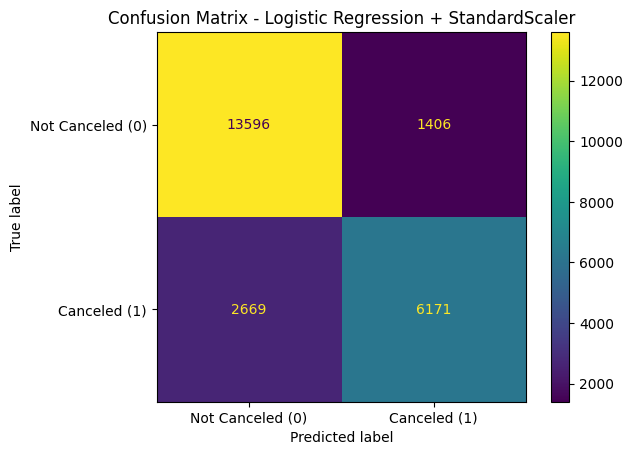

In [65]:
y_pred_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled (0)", "Canceled (1)"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_logistic_name}")
plt.show()


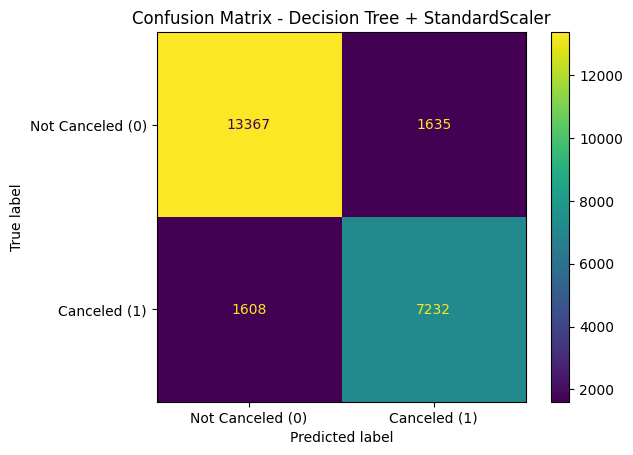

In [66]:
y_pred_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled (0)", "Canceled (1)"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_tree_name}")
plt.show()